# Lab Assignment - 4
## Logistic Regression on Breast Cancer Wisconsin (Diagnostic) Dataset

**Course:** AI in Healthcare  
**Course Code:** CSET343  
**Objective:** Preprocess a real-world medical dataset, train a logistic regression model, evaluate it, and interpret the results.


### Dataset
This lab uses the **Breast Cancer Wisconsin (Diagnostic)** dataset available through scikit-learn. It contains diagnostic measurements computed from digitized breast-mass images and a binary target indicating malignant/benign diagnosis.

In [1]:
# Install/import required libraries
!pip -q install scikit-learn pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## Task 1: Data Acquisition and Exploration

In [2]:
# 1. Load the Breast Cancer Wisconsin (Diagnostic) dataset
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# Rename the target column to Outcome for the assignment
df = df.rename(columns={'target': 'Outcome'})

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Convert target to binary with a clear medical interpretation:
# 1 = Malignant, 0 = Benign
# In sklearn: 0 = malignant and 1 = benign
df['Outcome'] = df['Outcome'].map({0: 1, 1: 0}).astype(int)

print('Target mapping: 1 = Malignant, 0 = Benign')
print(df['Outcome'].value_counts())

Target mapping: 1 = Malignant, 0 = Benign
Outcome
0    357
1    212
Name: count, dtype: int64


In [4]:
# 2. Summary statistics
summary = df.describe().T
summary['median'] = df.median(numeric_only=True)
summary = summary[['mean', 'median', 'std', 'min', 'max']]
display(summary)

,mean,median,std,min,max
mean radius,14.127292,13.370000,3.524049,6.981000,28.11000
mean texture,19.289649,18.840000,4.301036,9.710000,39.28000
mean perimeter,91.969033,86.240000,24.298981,43.790000,188.50000
mean area,654.889104,551.100000,351.914129,143.500000,2501.00000
mean smoothness,0.096360,0.095870,0.014064,0.052630,0.16340
mean compactness,0.104341,0.092630,0.052813,0.019380,0.34540
mean concavity,0.088799,0.061540,0.079720,0.000000,0.42680
mean concave points,0.048919,0.033500,0.038803,0.000000,0.20120
mean symmetry,0.181162,0.179200,0.027414,0.106000,0.30400
mean fractal dimension,0.062798,0.061540,0.007060,0.049960,0.09744


In [5]:
# 3. Missing values and duplicates
print('Total missing values:', df.isnull().sum().sum())
print('\nMissing values by column:')
display(df.isnull().sum()[df.isnull().sum() > 0])

print('Number of duplicate rows:', df.duplicated().sum())


Total missing values: 0

Missing values by column:


,0


Number of duplicate rows: 0


In [6]:
# Outlier detection using the IQR rule
X_temp = df.drop(columns='Outcome')
Q1 = X_temp.quantile(0.25)
Q3 = X_temp.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier_counts = ((X_temp < lower) | (X_temp > upper)).sum().sort_values(ascending=False)

print('Features with the highest number of IQR outliers:')
display(outlier_counts.head(15))

Features with the highest number of IQR outliers:


,0
area error,65
radius error,38
perimeter error,38
worst area,35
smoothness error,30
fractal dimension error,28
compactness error,28
symmetry error,27
mean area,25
worst fractal dimension,24


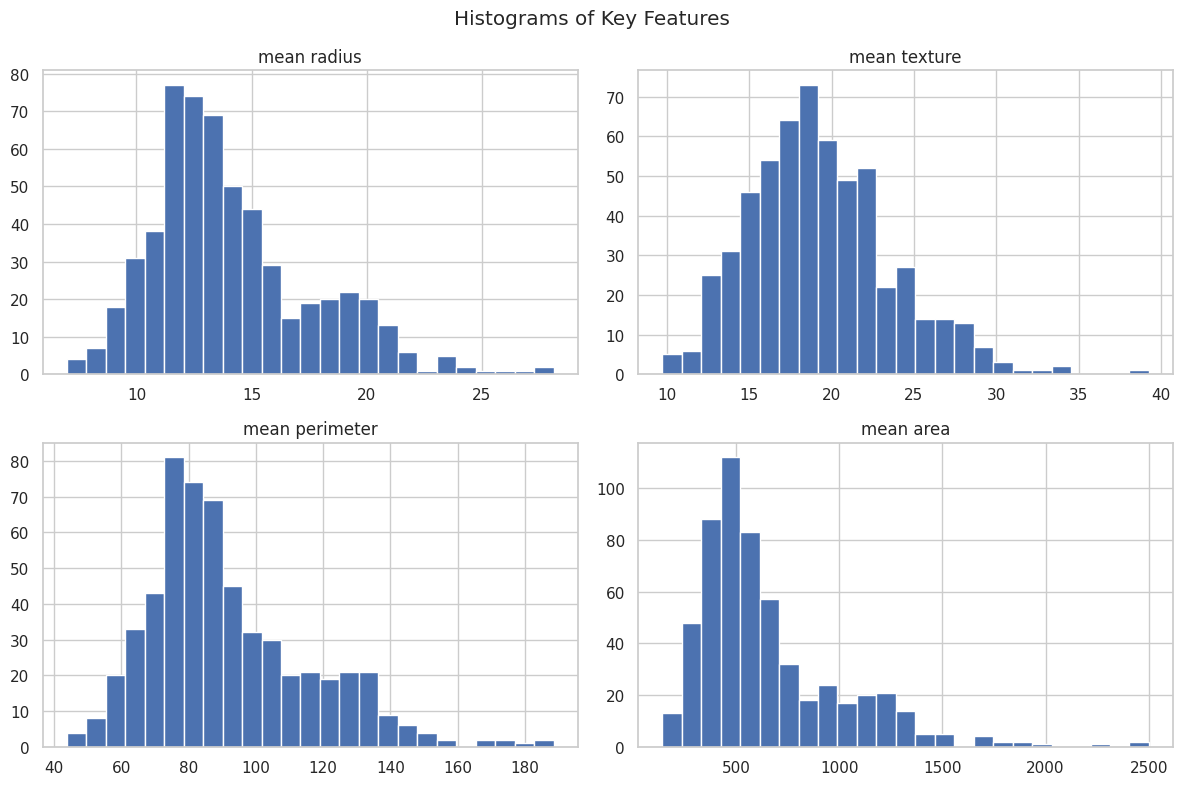

In [7]:
# 4A. Histograms for selected key features
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
df[key_features].hist(figsize=(12, 8), bins=25)
plt.suptitle('Histograms of Key Features')
plt.tight_layout()
plt.show()

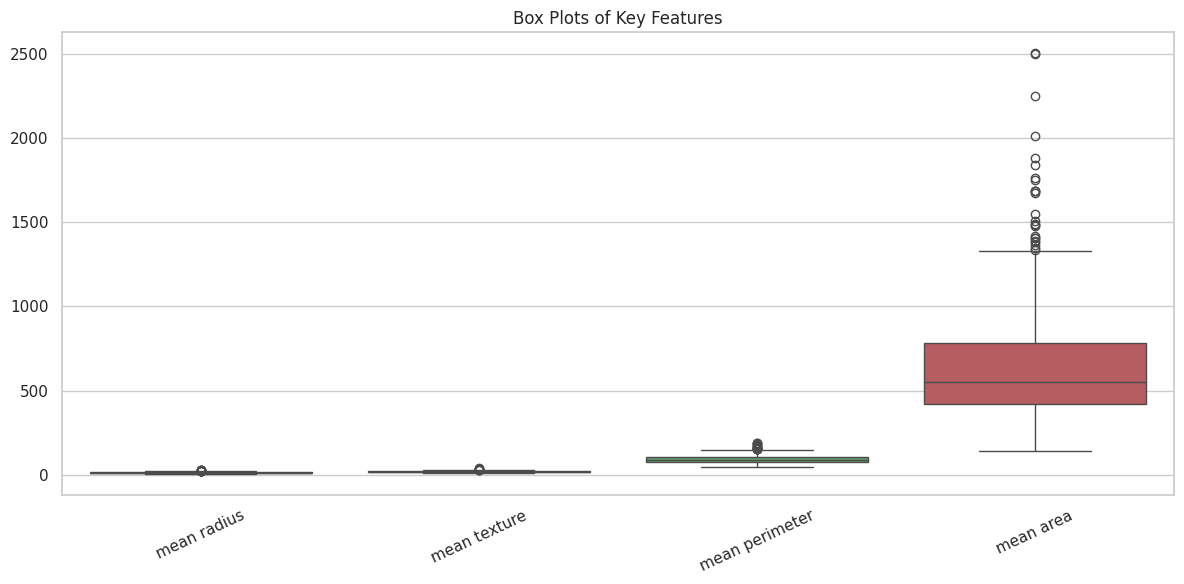

In [8]:
# 4B. Box plots for selected key features
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[key_features])
plt.xticks(rotation=25)
plt.title('Box Plots of Key Features')
plt.tight_layout()
plt.show()

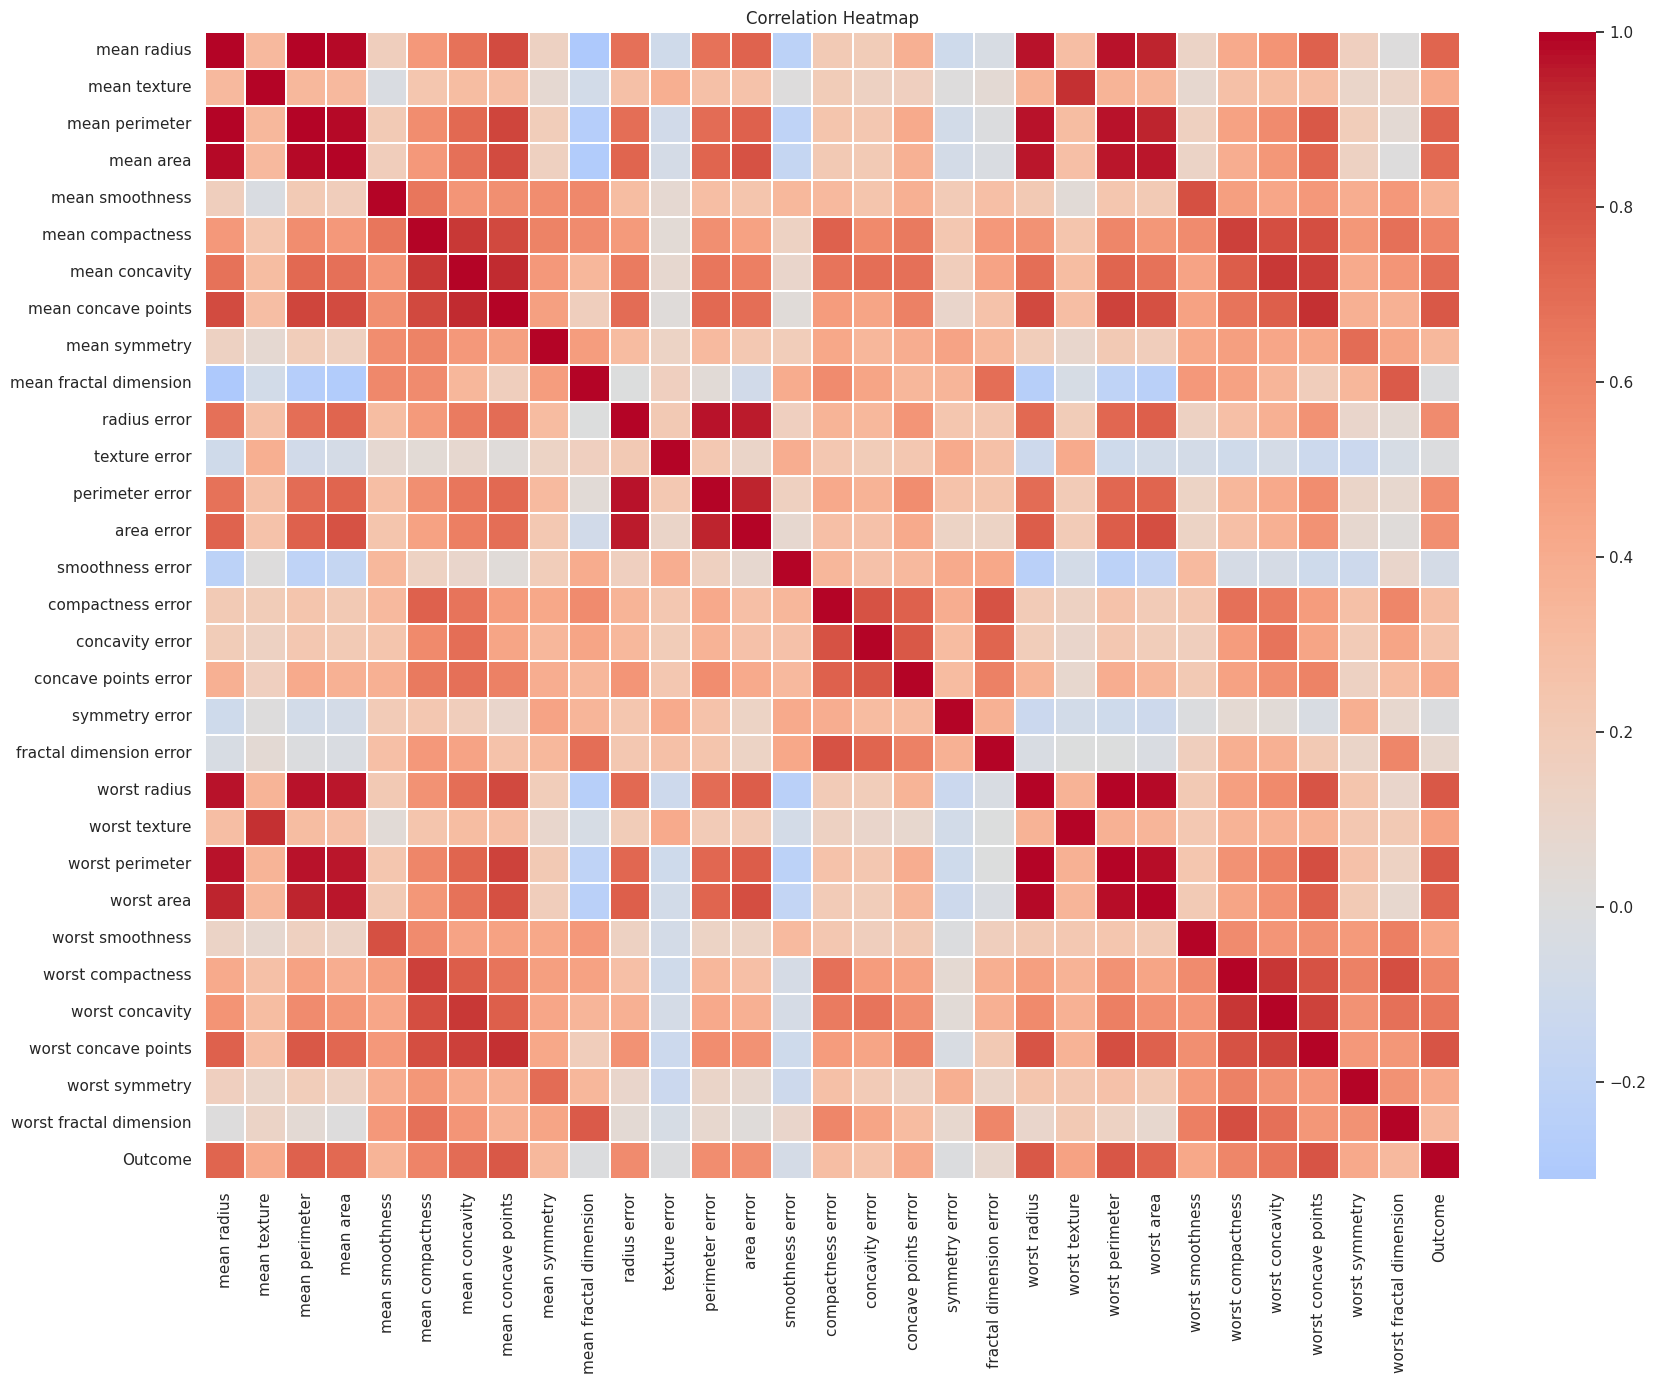

In [9]:
# 4C. Correlation heatmap
plt.figure(figsize=(18, 14))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

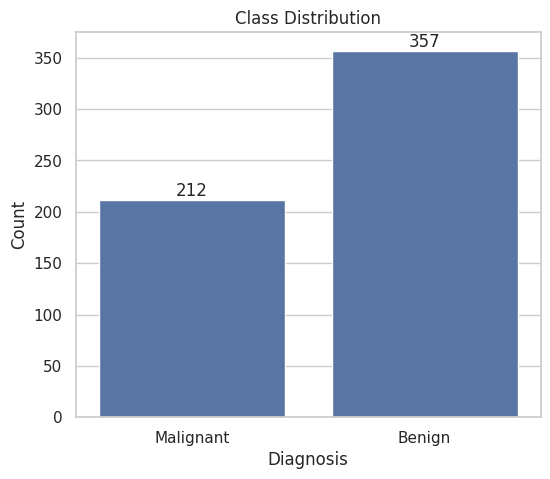

Outcome
Benign       357
Malignant    212
Name: count, dtype: int64

Class percentages:
Outcome
Benign       62.74
Malignant    37.26
Name: count, dtype: float64


In [10]:
# 4D. Class distribution
class_counts = df['Outcome'].map({0: 'Benign', 1: 'Malignant'}).value_counts()

plt.figure(figsize=(6, 5))
ax = sns.countplot(x=df['Outcome'].map({0: 'Benign', 1: 'Malignant'}))
plt.title('Class Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

print(class_counts)
print('\nClass percentages:')
print((class_counts / len(df) * 100).round(2))

### Task 1 Discussion
- The dataset contains two diagnosis classes: benign and malignant.
- The class counts are not exactly equal, so stratified splitting is used to preserve the class proportions in training and testing data.
- Missing values and duplicate rows are checked explicitly.
- IQR-based outlier detection is performed. Outliers are handled later using training-set-based IQR capping to reduce the effect of extreme values without leaking information from the test set.
- In a medical diagnosis problem, class imbalance can affect model performance and accuracy alone may not describe the model completely. Precision, recall, F1-score, confusion matrix and ROC-AUC are therefore also reported.

## Task 2: Data Preprocessing

In [11]:
# Separate features and target
X = df.drop(columns='Outcome')
y = df['Outcome']

# 80/20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training set:', X_train.shape)
print('Testing set :', X_test.shape)
print('\nTraining class distribution:')
print(y_train.value_counts(normalize=True).sort_index())
print('\nTesting class distribution:')
print(y_test.value_counts(normalize=True).sort_index())

Training set: (455, 30)
Testing set : (114, 30)

Training class distribution:
Outcome
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing class distribution:
Outcome
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [12]:
# Handle outliers using IQR capping fitted ONLY on training data.
# This avoids using information from the test set during preprocessing.
Q1_train = X_train.quantile(0.25)
Q3_train = X_train.quantile(0.75)
IQR_train = Q3_train - Q1_train
lower_train = Q1_train - 1.5 * IQR_train
upper_train = Q3_train + 1.5 * IQR_train

X_train_capped = X_train.clip(lower=lower_train, upper=upper_train, axis=1)
X_test_capped = X_test.clip(lower=lower_train, upper=upper_train, axis=1)

print('Outlier capping completed using training-set IQR limits.')

Outlier capping completed using training-set IQR limits.


In [13]:
# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_capped)
X_test_scaled = scaler.transform(X_test_capped)

print('Feature standardization completed.')

# Check approximately zero mean and unit standard deviation on training data
print('First 5 training feature means:', np.round(X_train_scaled.mean(axis=0)[:5], 4))
print('First 5 training feature stds  :', np.round(X_train_scaled.std(axis=0)[:5], 4))

Feature standardization completed.
First 5 training feature means: [-0.  0. -0.  0.  0.]
First 5 training feature stds  : [1. 1. 1. 1. 1.]


## Task 3: Model Training and Basic Evaluation

In [14]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression model trained successfully.')

Logistic Regression model trained successfully.


In [15]:
# Accuracy, precision, recall and F1-score
accuracy = accuracy_score(y_test, y_pred)

precision_malignant = precision_score(y_test, y_pred, pos_label=1)
recall_malignant = recall_score(y_test, y_pred, pos_label=1)
f1_malignant = f1_score(y_test, y_pred, pos_label=1)

precision_benign = precision_score(y_test, y_pred, pos_label=0)
recall_benign = recall_score(y_test, y_pred, pos_label=0)
f1_benign = f1_score(y_test, y_pred, pos_label=0)

print(f'Accuracy: {accuracy:.4f}')
print('\nMalignant (1):')
print(f'Precision: {precision_malignant:.4f}')
print(f'Recall   : {recall_malignant:.4f}')
print(f'F1-score : {f1_malignant:.4f}')
print('\nBenign (0):')
print(f'Precision: {precision_benign:.4f}')
print(f'Recall   : {recall_benign:.4f}')
print(f'F1-score : {f1_benign:.4f}')

Accuracy: 0.9649

Malignant (1):
Precision: 0.9750
Recall   : 0.9286
F1-score : 0.9512

Benign (0):
Precision: 0.9595
Recall   : 0.9861
F1-score : 0.9726


In [16]:
# Full classification report
print(classification_report(
    y_test, y_pred,
    target_names=['Benign', 'Malignant'],
    digits=4
))

              precision    recall  f1-score   support

      Benign     0.9595    0.9861    0.9726        72
   Malignant     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114



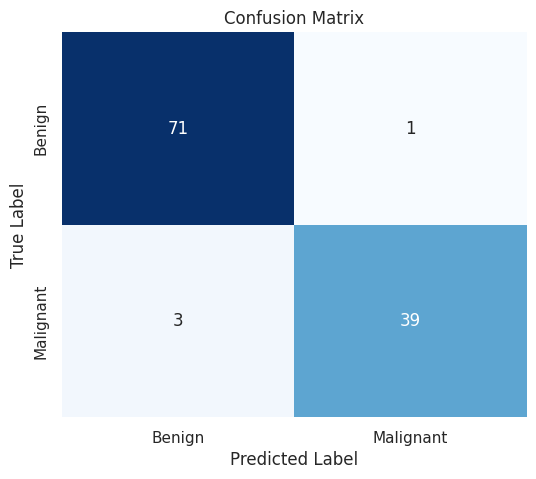

Confusion matrix:
[[71  1]
 [ 3 39]]


In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print('Confusion matrix:')
print(cm)

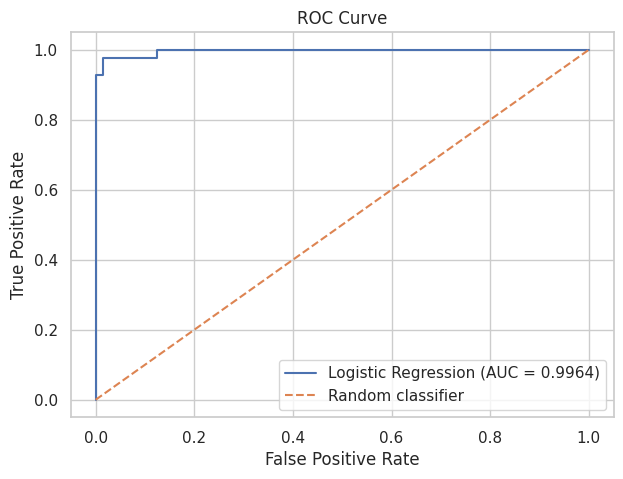

ROC-AUC: 0.9964


In [18]:
# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f'ROC-AUC: {auc_score:.4f}')

## Model Interpretation

The evaluation metrics should be interpreted together. **Accuracy** gives the overall proportion of correct predictions. **Precision** indicates how many predicted cases of a class are actually that class, while **recall** indicates how many actual cases of a class are detected. **F1-score** combines precision and recall. The **confusion matrix** shows the exact counts of correct and incorrect predictions. **ROC-AUC** summarizes the model's ability to distinguish the two classes across classification thresholds.

For a medical diagnosis task, recall for the malignant class is particularly important to inspect because false-negative predictions correspond to malignant cases that the model does not identify. The model metrics here are for educational evaluation on this dataset and should not be treated as a clinical diagnostic system.

In [19]:
# Optional: inspect logistic regression coefficients
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
coef_table['Absolute_Coefficient'] = coef_table['Coefficient'].abs()
coef_table = coef_table.sort_values('Absolute_Coefficient', ascending=False)
display(coef_table.head(15))

,Feature,Coefficient,Absolute_Coefficient
21,worst texture,1.464648,1.464648
13,area error,1.158545,1.158545
28,worst symmetry,1.050379,1.050379
15,compactness error,-1.018275,1.018275
7,mean concave points,0.906850,0.906850
10,radius error,0.874389,0.874389
26,worst concavity,0.835842,0.835842
23,worst area,0.794356,0.794356
6,mean concavity,0.749805,0.749805
19,fractal dimension error,-0.700057,0.700057


## Final Conclusion

Logistic regression was trained on the Breast Cancer Wisconsin (Diagnostic) dataset after checking data quality, handling outliers, performing a stratified 80/20 split, and standardizing the features. The model was evaluated using accuracy, precision, recall, F1-score, confusion matrix, ROC curve and AUC. The results demonstrate how logistic regression can be applied to a binary medical classification problem while showing why multiple evaluation metrics are necessary.